# Lab Assignment - 8

### CS22B1093 - Rohan G

---------------

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import time
import random

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


[nltk_data] Downloading package punkt to /home/rzeta/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/rzeta/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/rzeta/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
train_data = pd.read_parquet('sst2_sentiment_dataset/sst2_train.parquet')
val_data   = pd.read_parquet('sst2_sentiment_dataset/sst2_valid.parquet')

train_df, test_df = train_test_split(train_data, test_size=5000, random_state=SEED, stratify=train_data['label'])

print(f"Train set size: {train_df.shape[0]}")
print(f"Test set size:  {test_df.shape[0]}")
print(f"Val  set size:  {val_data.shape[0]}")

Train set size: 62349
Test set size:  5000
Val  set size:  872


In [ ]:
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove special chars & numbers (but keep spaces and letters)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords - BUT keep 'not'
    stop_words = set(stopwords.words('english'))
    # Forcefully remove 'not' from the stopwords list (so "not" is kept in data)
    if 'not' in stop_words:
        stop_words.remove('not')

    # Lemmatize & remove (filtered) stopwords
    lemmatizer = WordNetLemmatizer()
    filtered_tokens = []
    for w in tokens:
        if w not in stop_words:
            filtered_tokens.append(lemmatizer.lemmatize(w))

    # If all tokens are removed, keep <unk>
    if len(filtered_tokens) == 0:
        filtered_tokens = ["<unk>"]

    # Join
    return ' '.join(filtered_tokens)

train_df['processed_text'] = train_df['sentence'].apply(preprocess_text)
test_df['processed_text']  = test_df['sentence'].apply(preprocess_text)
val_data['processed_text'] = val_data['sentence'].apply(preprocess_text)

In [ ]:
def build_vocab(texts, max_vocab_size=10000):
    all_words = []
    for txt in texts:
        all_words.extend(txt.split())
    word_counts = Counter(all_words)
    
    vocab = ["<PAD>", "<UNK>"]  
    # Get top (max_vocab_size - 2) words
    vocab.extend([w for w, _ in word_counts.most_common(max_vocab_size - len(vocab))])
    
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for i, w in enumerate(vocab)}
    return vocab, word2idx, idx2word

MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 200

vocab, word2idx, idx2word = build_vocab(train_df['processed_text'], MAX_VOCAB_SIZE)
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")

Vocab size: 10000


In [8]:
def text_to_sequence(text, word2idx, max_length=MAX_SEQUENCE_LENGTH):
    words = text.split()
    seq = [word2idx.get(w, word2idx["<UNK>"]) for w in words]
    # Truncate if longer than max_length
    if len(seq) > max_length:
        seq = seq[:max_length]
    return seq

train_sequences = [text_to_sequence(t, word2idx) for t in train_df['processed_text']]
test_sequences  = [text_to_sequence(t, word2idx) for t in test_df['processed_text']]
val_sequences   = [text_to_sequence(t, word2idx) for t in val_data['processed_text']]

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq   = torch.tensor(self.sequences[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        length= torch.tensor(len(self.sequences[idx]), dtype=torch.long)
        return seq, label, length

def collate_fn(batch):
    sequences, labels, lengths = zip(*batch)
    
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=word2idx["<PAD>"])
    labels = torch.tensor(labels, dtype=torch.float)
    lengths= torch.tensor(lengths, dtype=torch.long)
    
    return padded_sequences, labels, lengths

BATCH_SIZE = 64

train_dataset = SentimentDataset(train_sequences, train_df['label'].values)
test_dataset  = SentimentDataset(test_sequences,  test_df['label'].values)
val_dataset   = SentimentDataset(val_sequences,   val_data['label'].values)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


In [ ]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers,
                 bidirectional, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            nonlinearity='tanh',
            bidirectional=bidirectional,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text, text_lengths):
        embedded = self.embedding(text)
        
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, text_lengths.cpu(), 
                                                            batch_first=True, enforce_sorted=False)
        packed_output, hidden = self.rnn(packed_embedded)
        
        if self.rnn.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        
        hidden = self.dropout(hidden)
        out = self.fc(hidden).squeeze(1)
        return out

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, 
                 bidirectional, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), output_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, text, text_lengths):
        embedded = self.embedding(text)
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, text_lengths.cpu(),
                                                            batch_first=True, enforce_sorted=False)
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        
        hidden = self.dropout(hidden)
        out = self.fc(hidden).squeeze(1)
        return out

In [ ]:
def train_model(model, iterator, optimizer, criterion, clip=1.0):
    epoch_loss = 0
    epoch_acc  = 0
    model.train()
    
    for batch in iterator:
        text, labels, text_lengths = batch
        text       = text.to(device)
        labels     = labels.to(device)
        text_lengths = text_lengths.to(device)
        
        optimizer.zero_grad()
        predictions = model(text, text_lengths)
        
        loss = criterion(predictions, labels)
        # Accuracy
        preds = torch.round(torch.sigmoid(predictions))
        correct = (preds == labels).float().sum()
        acc  = correct / len(labels)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc  += acc.item()
    
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [13]:
def evaluate_model(model, iterator, criterion):
    epoch_loss = 0
    epoch_acc  = 0
    model.eval()
    
    with torch.no_grad():
        for batch in iterator:
            text, labels, text_lengths = batch
            text       = text.to(device)
            labels     = labels.to(device)
            text_lengths = text_lengths.to(device)
            
            predictions = model(text, text_lengths)
            loss = criterion(predictions, labels)
            
            preds = torch.round(torch.sigmoid(predictions))
            correct = (preds == labels).float().sum()
            acc = correct / len(labels)
            
            epoch_loss += loss.item()
            epoch_acc  += acc.item()
    
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def epoch_time(start_time, end_time):
    elapsed = end_time - start_time
    mins = int(elapsed // 60)
    secs = int(elapsed - (mins * 60))
    return mins, secs

In [ ]:
EMBEDDING_DIM_RNN = 300
HIDDEN_DIM_RNN    = 256 
N_LAYERS_RNN      = 2
BIDIRECTIONAL_RNN = True
DROPOUT_RNN       = 0.3 
LEARNING_RATE_RNN = 0.001
N_EPOCHS_RNN      = 15   

rnn_model = SentimentRNN(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM_RNN,
    hidden_dim=HIDDEN_DIM_RNN,
    output_dim=1,
    n_layers=N_LAYERS_RNN,
    bidirectional=BIDIRECTIONAL_RNN,
    dropout=DROPOUT_RNN,
    pad_idx=word2idx["<PAD>"]
).to(device)

EMBEDDING_DIM_LSTM = 300
HIDDEN_DIM_LSTM    = 512  
N_LAYERS_LSTM      = 2
BIDIRECTIONAL_LSTM = True
DROPOUT_LSTM       = 0.3
LEARNING_RATE_LSTM = 0.001
N_EPOCHS_LSTM      = 15

lstm_model = LSTMModel(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM_LSTM,
    hidden_dim=HIDDEN_DIM_LSTM,
    output_dim=1,
    n_layers=N_LAYERS_LSTM,
    bidirectional=BIDIRECTIONAL_LSTM,
    dropout=DROPOUT_LSTM,
    pad_idx=word2idx["<PAD>"]
).to(device)

criterion = nn.BCEWithLogitsLoss()

In [15]:
print("\n=============================")
print("TRAINING RNN MODEL")
print("=============================")
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=LEARNING_RATE_RNN)

best_val_loss_rnn = float('inf')
patience_rnn = 3
stop_counter_rnn = 0

train_losses_rnn, train_accs_rnn = [], []
val_losses_rnn, val_accs_rnn     = [], []

for epoch in range(N_EPOCHS_RNN):
    start_time = time.time()

    train_loss, train_acc = train_model(rnn_model, train_loader, rnn_optimizer, criterion, clip=1.0)
    val_loss,   val_acc   = evaluate_model(rnn_model, val_loader, criterion)
    
    train_losses_rnn.append(train_loss)
    train_accs_rnn.append(train_acc)
    val_losses_rnn.append(val_loss)
    val_accs_rnn.append(val_acc)
    
    # Early stopping logic
    if val_loss < best_val_loss_rnn:
        best_val_loss_rnn = val_loss
        torch.save(rnn_model.state_dict(), 'best-rnn-model.pt')
        stop_counter_rnn = 0
    else:
        stop_counter_rnn += 1
        if stop_counter_rnn >= patience_rnn:
            print(f"RNN early stopping at epoch {epoch+1}")
            break
    
    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    
    print(f"Epoch [{epoch+1}/{N_EPOCHS_RNN}] | Time: {epoch_mins}m {epoch_secs}s")
    print(f"  Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val.  Loss: {val_loss:.3f} | Val.  Acc: {val_acc*100:.2f}%")


TRAINING RNN MODEL
Epoch [1/15] | Time: 0m 7s
  Train Loss: 0.472 | Train Acc: 77.04%
  Val.  Loss: 0.550 | Val.  Acc: 75.27%
Epoch [2/15] | Time: 0m 6s
  Train Loss: 0.264 | Train Acc: 89.19%
  Val.  Loss: 0.560 | Val.  Acc: 76.45%
Epoch [3/15] | Time: 0m 6s
  Train Loss: 0.187 | Train Acc: 92.76%
  Val.  Loss: 0.578 | Val.  Acc: 75.11%
RNN early stopping at epoch 4


In [ ]:
print("\n=============================")
print("TRAINING LSTM MODEL")
print("=============================")
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE_LSTM)

best_val_loss_lstm = float('inf')
patience_lstm = 3
stop_counter_lstm = 0

train_losses_lstm, train_accs_lstm = [], []
val_losses_lstm, val_accs_lstm     = [], []

for epoch in range(N_EPOCHS_LSTM):
    start_time = time.time()

    train_loss, train_acc = train_model(lstm_model, train_loader, lstm_optimizer, criterion, clip=1.0)
    val_loss,   val_acc   = evaluate_model(lstm_model, val_loader, criterion)
    
    train_losses_lstm.append(train_loss)
    train_accs_lstm.append(train_acc)
    val_losses_lstm.append(val_loss)
    val_accs_lstm.append(val_acc)
    
    if val_loss < best_val_loss_lstm:
        best_val_loss_lstm = val_loss
        torch.save(lstm_model.state_dict(), 'best-lstm-model.pt')
        stop_counter_lstm = 0
    else:
        stop_counter_lstm += 1
        if stop_counter_lstm >= patience_lstm:
            print(f"LSTM early stopping at epoch {epoch+1}")
            break
    
    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    
    print(f"Epoch [{epoch+1}/{N_EPOCHS_LSTM}] | Time: {epoch_mins}m {epoch_secs}s")
    print(f"  Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val.  Loss: {val_loss:.3f} | Val.  Acc: {val_acc*100:.2f}%")


TRAINING LSTM MODEL
Epoch [1/15] | Time: 0m 13s
  Train Loss: 0.395 | Train Acc: 81.29%
  Val.  Loss: 0.563 | Val.  Acc: 76.38%
Epoch [2/15] | Time: 0m 13s
  Train Loss: 0.192 | Train Acc: 92.36%
  Val.  Loss: 0.488 | Val.  Acc: 79.08%
Epoch [3/15] | Time: 0m 13s
  Train Loss: 0.117 | Train Acc: 95.32%
  Val.  Loss: 0.625 | Val.  Acc: 78.24%
Epoch [4/15] | Time: 0m 13s
  Train Loss: 0.080 | Train Acc: 96.67%
  Val.  Loss: 0.683 | Val.  Acc: 77.57%
LSTM early stopping at epoch 5


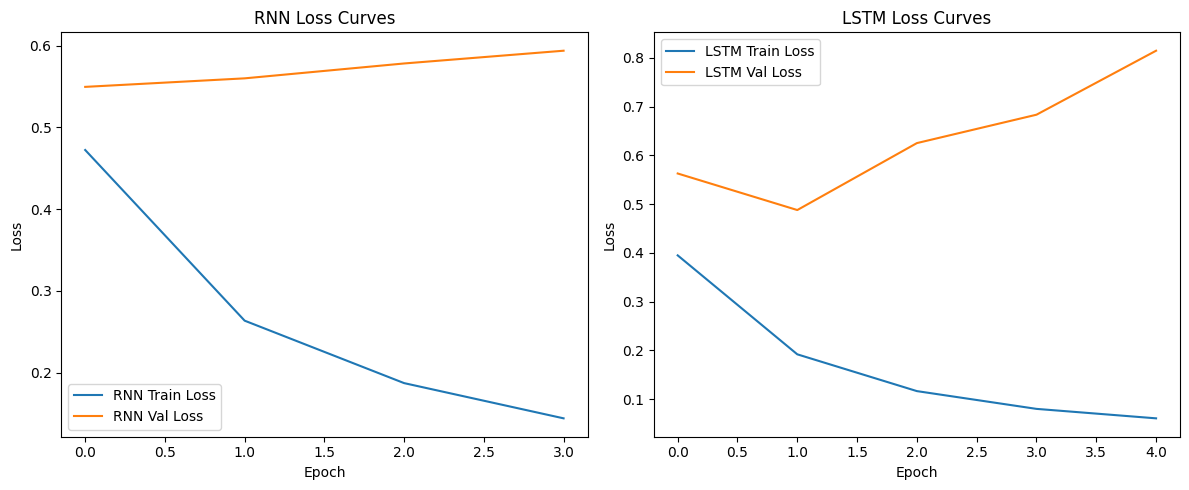

In [17]:
plt.figure(figsize=(12,5))

# RNN
plt.subplot(1,2,1)
plt.plot(train_losses_rnn, label='RNN Train Loss')
plt.plot(val_losses_rnn,   label='RNN Val Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN Loss Curves')

# LSTM
plt.subplot(1,2,2)
plt.plot(train_losses_lstm, label='LSTM Train Loss')
plt.plot(val_losses_lstm,   label='LSTM Val Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss Curves')

plt.tight_layout()
plt.show()

In [18]:
print("\nLoading best RNN model for final test evaluation...")
rnn_model.load_state_dict(torch.load('best-rnn-model.pt'))
test_loss_rnn, test_acc_rnn = evaluate_model(rnn_model, test_loader, criterion)
print(f"RNN Test Loss: {test_loss_rnn:.3f} | RNN Test Acc: {test_acc_rnn*100:.2f}%")

print("\nLoading best LSTM model for final test evaluation...")
lstm_model.load_state_dict(torch.load('best-lstm-model.pt'))
test_loss_lstm, test_acc_lstm = evaluate_model(lstm_model, test_loader, criterion)
print(f"LSTM Test Loss: {test_loss_lstm:.3f} | LSTM Test Acc: {test_acc_lstm*100:.2f}%")


Loading best RNN model for final test evaluation...
RNN Test Loss: 0.354 | RNN Test Acc: 84.57%

Loading best LSTM model for final test evaluation...
LSTM Test Loss: 0.251 | LSTM Test Acc: 90.51%


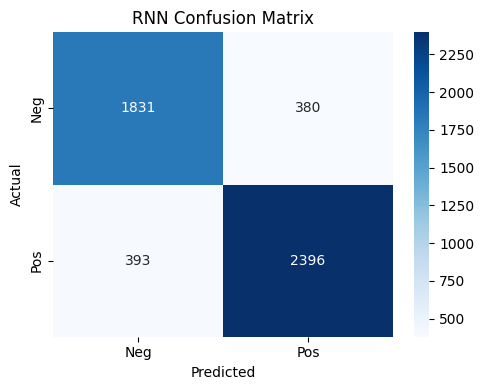


RNN Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.83      0.83      2211
    Positive       0.86      0.86      0.86      2789

    accuracy                           0.85      5000
   macro avg       0.84      0.84      0.84      5000
weighted avg       0.85      0.85      0.85      5000

RNN Accuracy:  0.8454


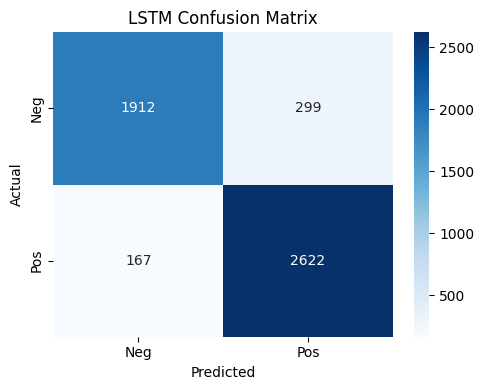


LSTM Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.86      0.89      2211
    Positive       0.90      0.94      0.92      2789

    accuracy                           0.91      5000
   macro avg       0.91      0.90      0.90      5000
weighted avg       0.91      0.91      0.91      5000

LSTM Accuracy: 0.9068


In [19]:
def get_predictions(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            text, labels, text_lengths = batch
            text       = text.to(device)
            text_lengths = text_lengths.to(device)
            
            outputs = model(text, text_lengths)
            preds   = torch.round(torch.sigmoid(outputs))
            
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
    return np.array(y_true), np.array(y_pred)

from sklearn.metrics import confusion_matrix

# RNN
rnn_y_true, rnn_y_pred = get_predictions(rnn_model, test_loader)
rnn_cm = confusion_matrix(rnn_y_true, rnn_y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(rnn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
plt.title('RNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nRNN Classification Report:")
print(classification_report(rnn_y_true, rnn_y_pred, target_names=['Negative','Positive']))
print(f"RNN Accuracy:  {accuracy_score(rnn_y_true, rnn_y_pred):.4f}")

# LSTM
lstm_y_true, lstm_y_pred = get_predictions(lstm_model, test_loader)
lstm_cm = confusion_matrix(lstm_y_true, lstm_y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nLSTM Classification Report:")
print(classification_report(lstm_y_true, lstm_y_pred, target_names=['Negative','Positive']))
print(f"LSTM Accuracy: {accuracy_score(lstm_y_true, lstm_y_pred):.4f}")

In [ ]:
def predict_sentiment(model, text, word2idx, device):
    model.eval()
    # Preprocess
    processed_text = preprocess_text(text)
    seq = text_to_sequence(processed_text, word2idx)
    seq_tensor = torch.tensor([seq], dtype=torch.long).to(device)
    seq_length = torch.tensor([len(seq)], dtype=torch.long).to(device)
    
    with torch.no_grad():
        output = torch.sigmoid(model(seq_tensor, seq_length))
    sentiment = "Positive" if output.item() > 0.5 else "Negative"
    probability = output.item() if sentiment=="Positive" else 1 - output.item()
    return sentiment, probability

example_reviews = [
    "I absolutely loved this movie. The story and acting were fantastic!",
    "This film was not good at all. I almost fell asleep.",
    "It's just okay, nothing great, nothing terrible, quite average."
]

print("\nExample Predictions (RNN):")
for review in example_reviews:
    s, p = predict_sentiment(rnn_model, review, word2idx, device)
    print(f"Review: {review}")
    print(f"  => Sentiment: {s} (Confidence: {p:.4f})\n")

print("Example Predictions (LSTM):")
for review in example_reviews:
    s, p = predict_sentiment(lstm_model, review, word2idx, device)
    print(f"Review: {review}")
    print(f"  => Sentiment: {s} (Confidence: {p:.4f})\n")


Example Predictions (RNN):
Review: I absolutely loved this movie. The story and acting were fantastic!
  => Sentiment: Positive (Confidence: 0.9815)

Review: This film was not good at all. I almost fell asleep.
  => Sentiment: Negative (Confidence: 0.9607)

Review: It's just okay, nothing great, nothing terrible, quite average.
  => Sentiment: Negative (Confidence: 0.8333)

Example Predictions (LSTM):
Review: I absolutely loved this movie. The story and acting were fantastic!
  => Sentiment: Positive (Confidence: 0.9904)

Review: This film was not good at all. I almost fell asleep.
  => Sentiment: Negative (Confidence: 0.9746)

Review: It's just okay, nothing great, nothing terrible, quite average.
  => Sentiment: Negative (Confidence: 0.9250)



--------------